[Gold, Silver & Precious Metals Futures Daily Data](https://www.kaggle.com/datasets/guillemservera/precious-metals-data)

# STAT5291 Project Code

In [30]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime, timedelta

In [ ]:


df = pd.read_csv('all_commodities_data.csv')
df.columns = ['Ticker', 'Commodity', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df['Commodity'].unique()

# 从yahoo finance上获取数据
ticker_list = ['GC=F', 'SI=F', 'PL=F', 'HG=F', 'PA=F']
comm_list = ['Gold', 'Silver', 'Platinum', 'Copper', 'Palladium']

end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)
def yfinance_fetch_price(ticker_name, comm_name, start=start_date):
    ticker = yf.Ticker(ticker_name)
    df1 = ticker.history(start=start, end=pd.Timestamp.now())
    df1.drop(columns=['Dividends', 'Stock Splits'], inplace=True)
    df1.reset_index(inplace=True)
    df1['Date'] = df1['Date'].map(lambda x: x.strftime('%Y/%m/%d'))
    df1.drop_duplicates(subset=['Date'], keep='first')
    df1['Ticker'] = ticker_name
    df1['Commodity'] = comm_name
    return df1
bdf = pd.DataFrame()


for ticker, commodity in zip(ticker_list, comm_list):
    temp_df = yfinance_fetch_price(ticker, commodity)
    bdf = pd.concat([bdf,temp_df])
bdf.to_csv('all_commodities_data1.csv')
# df = pd.concat([df, bdf])
# df.reset_index(inplace=True)
# # 保存到csv文件
# df.to_csv('all_commodities_data1.csv')


# S&P500 and VIX Data Download

In [ ]:
# Download 20 years of S&P 500 data
ticker = "^GSPC"  # S&P 500 symbol
end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)

# Download the data
sp500_data = yf.download(ticker, start=start_date, end=end_date)
sp500_data.reset_index(inplace=True)
sp500_data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volumn']
sp500_data = sp500_data[['Date', 'Close']]
sp500_data.to_csv('sp500.csv',index=False)

# --- VIX ---
# VIX指数的代码是 ^VIX
ticker = "^VIX"
end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)

# 下载VIX数据
vix_data = yf.download(ticker, start=start_date, end=end_date)
vix_data = vix_data.reset_index()
vix_data = vix_data[['Date', 'Close']]
vix_data.columns = ['Date', 'Close']

# 保存为CSV文件
vix_data.to_csv('vix.csv',index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
# 拆分每个资产到分表中
# import pandas as pd
# import numpy as np
# df = pd.read_csv('all_commodities_data.csv')

# comm_list = ['Gold', 'Silver', 'Platinum', 'Copper', 'Palladium']
# for commodity in comm_list:
#     comm_df = df[df['Commodity'] == commodity]
#     comm_df = comm_df.drop(columns=['Open','High','Low'])
#     comm_df['Date'] = pd.to_datetime(comm_df['Date'], dayfirst=True)
#     comm_df = comm_df.drop_duplicates(subset=['Date'], keep='first')
#     comm_df.sort_values(by='Date',inplace=True)
#     comm_df['Daily_Return'] = df['Close'].pct_change() * 252
#     comm_df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) * 252
#     comm_df.to_csv(f'data/{commodity}.csv', index=False)

### Wrangling and Merge Data to data.csv

In [6]:
all_commodity = pd.read_csv('all_commodities_data1.csv')

pt = pd.pivot_table(all_commodity, 'Close', index='Date', columns='Commodity', aggfunc='sum')
pt.index = pd.to_datetime(pt.index, dayfirst=True)
pt = pt.sort_index()

sp500 = pd.read_csv('sp500.csv')
vix = pd.read_csv('vix.csv')

sp500 = sp500.set_index(sp500['Date'])
vix = vix.set_index(vix['Date'])
sp500.index = pd.to_datetime(sp500.index)
vix.index = pd.to_datetime(vix.index)

pt['sp500'] = sp500['Close']
pt['vix'] = vix['Close']

panic_days = pd.read_csv('data/panic_days.csv')
panic_day_list = pd.to_datetime(panic_days['Date'],dayfirst=True).tolist()
pt['is_panic_day'] = pt.index.isin(panic_day_list).astype(int)

pt.to_csv('data.csv')

C:\Users\jimmy\AppData\Local\Temp\ipykernel_31916\2551345704.py:4: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pt.index = pd.to_datetime(pt.index, dayfirst=True)


# Generate Time Series Plot

In [ ]:
def plot_time_series(df, date_col='Date', value_col='Close', 
                     title='Price Time Series', 
                     ylabel='Close Price (USD)',
                     figsize=(12, 6),
                     hline=None,
                     hline_color='red',
                     hline_style='--',
                     hline_label=None):
    """
    绘制时间序列数据图表
    
    参数:
        df: DataFrame, 包含日期和数值两列
        date_col: str, 日期列名，默认 'Date'
        value_col: str, 数值列名，默认 'Close'
        title: str, 图表标题
        ylabel: str, y轴标签
        figsize: tuple, 图表尺寸，默认 (12, 6)
        hline: float, 水平参考线的y值，默认 None（不绘制）
        hline_color: str, 参考线颜色，默认 'red'
        hline_style: str, 参考线样式，默认 '--'（虚线）
        hline_label: str, 参考线标签，默认 None
    """
    # 复制数据避免修改原始df
    data = df.copy()
    
    # 确保日期格式正确
    # data[date_col] = pd.to_datetime(data[date_col])
    # data = data.sort_values(date_col)
    
    # 创建图表
    plt.figure(figsize=figsize)
    sns.lineplot(data=data, x=date_col, y=value_col)
    
    # 添加水平参考线
    if hline is not None:
        label = hline_label if hline_label else f'Reference: {hline}'
        plt.axhline(y=hline, color=hline_color, linestyle=hline_style, 
                   linewidth=2, label=label, alpha=0.7)
        plt.legend()
    
    # 设置 x 轴格式为年份
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    
    # 设置标签和标题
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 使用示例
# plot_time_series(df)  # 不显示参考线
# plot_time_series(df, hline=50)  # 在y=50处显示红色虚线
# plot_time_series(df, hline=30, hline_color='blue', hline_label='Threshold')
# plot_time_series(df, hline=20, hline_style='-', hline_label='VIX High Alert')

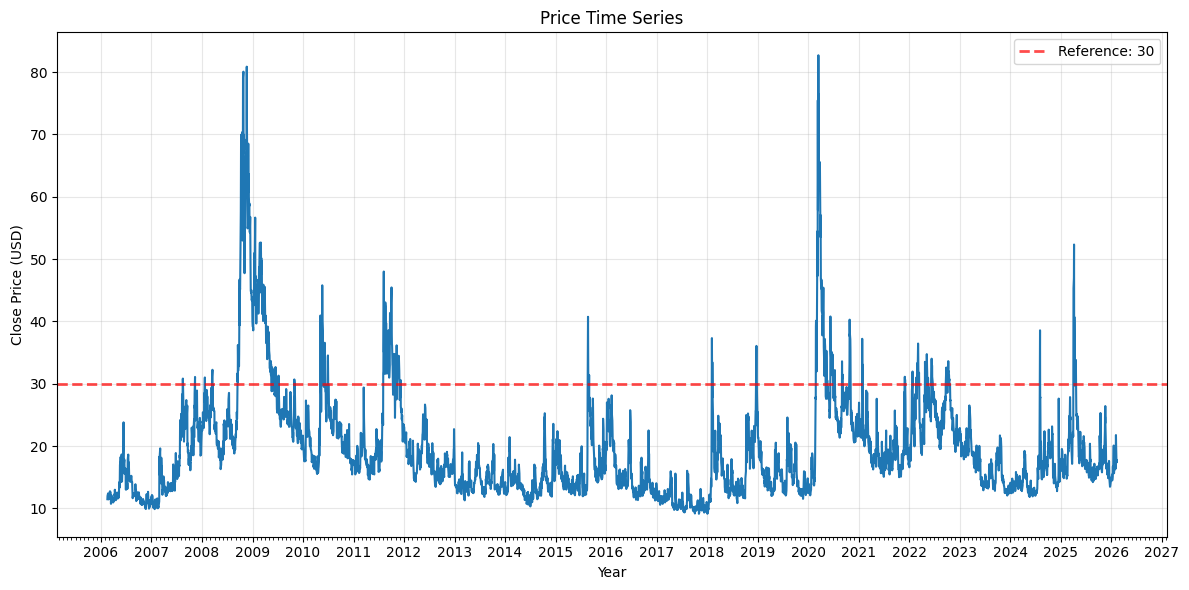

In [8]:
plot_time_series(vix_data, hline=30)

# Define Log Return Data

In [ ]:
data = pd.read_csv('data.csv')
data = data.set_index('Date')
data.columns
col = ['Copper', 'Gold', 'Palladium', 'Platinum', 'Silver', 'sp500']
log_returns = np.log(data[col]).diff()

Ret_data = pd.concat([log_returns, data[['vix','is_panic_day']]], axis=1)
Ret_data = Ret_data.iloc[1:]
Ret_data.to_csv('Ret_data.csv')


C:\Users\jimmy\AppData\Local\Temp\ipykernel_31916\3297108176.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  Ret_data.index = pd.to_datetime(Ret_data.index, dayfirst= True)


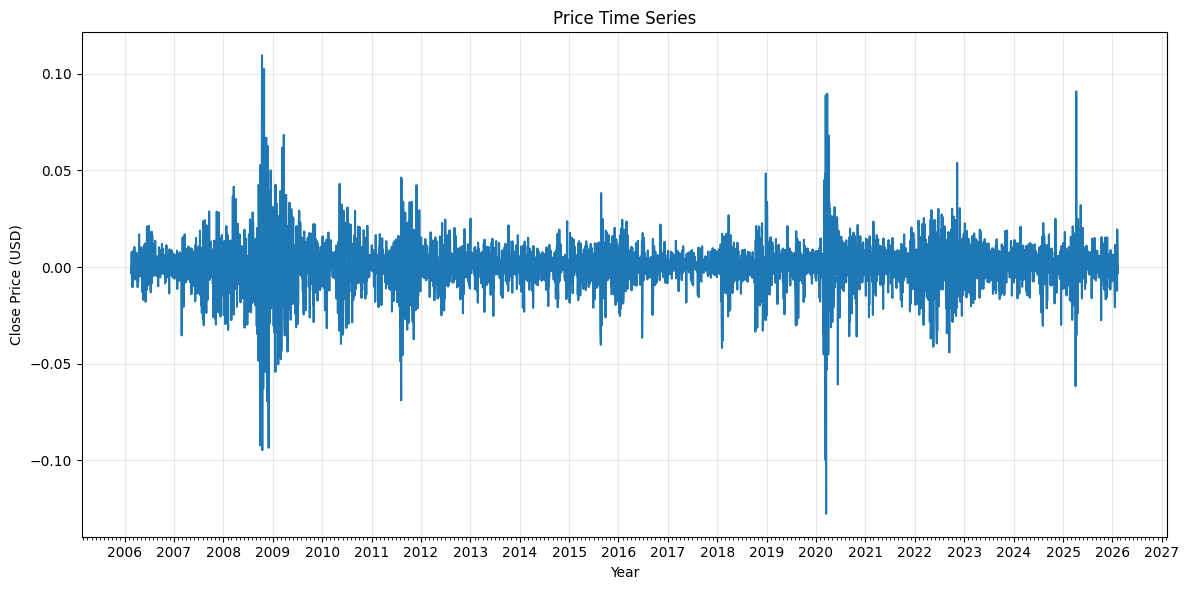

In [10]:
# Show Sample Graph
Ret_data.index = pd.to_datetime(Ret_data.index, dayfirst= True)
plot_time_series(Ret_data, date_col=Ret_data.index, value_col='sp500')

# Derive Descriptive Statistics

In [11]:
# OLD VERSION

# panic_day_df = Ret_data[Ret_data['is_panic_day'] == 1]
# non_panic_day_df = Ret_data[Ret_data['is_panic_day'] == 0]

# asset_list = ['Copper', 'Gold', 'Palladium', 'Platinum', 'Silver', 'sp500']
# regime_list = ['Normal(VIX < 30)', 'Extreme(VIX > 30)', 'Overall']

# stat_df = pd.DataFrame()

# stat_cols = ['Asset', 'Regime', 'Days', 'Return', "Volatility", "Skewness", "Kurtosis"]
# stat_df.columns = stat_cols
# for asset in asset_list:
#     for regime in regime_list:
#         temp_df = pd.DataFrame(data = {'Asset': [asset], 'Regime': [regime]})
#         if regime == 'Normal(VIX < 30)':
#             temp_df['Days'] = non_panic_day_df.shape[0]
#             temp_df["Return"] = np.mean(non_panic_day_df[asset]) * 252
#             temp_df["Volatility"] = np.std(non_panic_day_df[asset]) * np.sqrt(252)
#             temp_df['Skewness'] = non_panic_day_df[asset].skew()
#             temp_df['Kurtosis'] = non_panic_day_df[asset].kurt()
#         elif regime == 'Extreme(VIX > 30)':
#             temp_df['Days'] = panic_day_df.shape[0]
#             temp_df["Return"] = np.mean(panic_day_df[asset]) * 252
#             temp_df["Volatility"] = np.std(panic_day_df[asset]) * np.sqrt(252)
#             temp_df['Skewness'] = panic_day_df[asset].skew()
#             temp_df['Kurtosis'] = panic_day_df[asset].kurt()
#         else:
#             temp_df['Days'] = Ret_data.shape[0]
#             temp_df["Return"] = np.mean(Ret_data[asset]) * 252
#             temp_df["Volatility"] = np.std(Ret_data[asset]) * np.sqrt(252)
#             temp_df['Skewness'] = Ret_data[asset].skew()
#             temp_df['Kurtosis'] = Ret_data[asset].kurt()
#         stat_df = pd.concat([stat_df,temp_df])


In [14]:
# 1. 准备资产列表
asset_list = ['Gold', 'Silver', 'Copper', 'Platinum', 'Palladium', 'sp500']
results = []

# 2. 定义计算逻辑函数，避免代码重复
def get_stats(data_subset, asset_name, regime_name):
    series = data_subset[asset_name]
    return {
        'Asset': asset_name,
        'Regime': regime_name,
        'Days': len(series),
        'Return': series.mean() * 252,
        'Volatility': series.std() * np.sqrt(252),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt()
    }

# 3. 循环计算并存入列表
for asset in asset_list:
    # 计算 Normal
    results.append(get_stats(Ret_data[Ret_data['is_panic_day'] == 0], asset, 'Normal(VIX < 30)'))
    
    # 计算 Extreme
    results.append(get_stats(Ret_data[Ret_data['is_panic_day'] == 1], asset, 'Extreme(VIX > 30)'))
    
    # 计算 Overall
    results.append(get_stats(Ret_data, asset, 'Overall'))

# 4. 一次性生成最终表格
stat_df = pd.DataFrame(results)

# 5. 美化：调整列顺序并四舍五入
stat_df = stat_df[['Asset', 'Regime', 'Days', 'Return', 'Volatility', 'Skewness', 'Kurtosis']].round(4)

stat_df = stat_df.set_index(['Asset', 'Regime'])
stat_df


Days  Return  Volatility  Skewness  Kurtosis
Asset     Regime                                                         
Gold      Normal(VIX < 30)   4585  0.1064      0.1678   -0.9328    8.3994
          Extreme(VIX > 30)   447  0.1421      0.2988    0.3104    1.8273
          Overall            5032  0.1096      0.1833   -0.5279    7.3135
Silver    Normal(VIX < 30)   4585  0.1469      0.3252   -1.8418   29.1127
          Extreme(VIX > 30)   447 -0.3190      0.5495   -0.5904    3.4590
          Overall            5032  0.1054      0.3510   -1.5665   21.9839
Copper    Normal(VIX < 30)   4585  0.1446      0.2544   -0.6920   15.8485
          Extreme(VIX > 30)   447 -0.9088      0.4798   -0.0182    1.3026
          Overall            5032  0.0509      0.2824   -0.5879   11.5058
Platinum  Normal(VIX < 30)   4585  0.0907      0.2598   -0.8736   11.4946
          Extreme(VIX > 30)   447 -0.8584      0.4114   -0.5104    3.6132
          Overall            5032  0.0228      0.2738   -0.8749   10.3734
Palladium Normal(VIX < 30)   4585  0.1774      0.3448   -0.3826    5.2733
          Extreme(VIX > 30)   447 -0.9920      0.5966   -0.3689    7.7077
          Overall            5032  0.0717      0.3750   -0.4855    8.6071
sp500     Normal(VIX < 30)   4585  0.1862      0.1414   -0.1924    2.1129
          Extreme(VIX > 30)   447 -0.9351      0.4692    0.0427    1.8861
          Overall            5032  0.0863      0.1955   -0.4773   12.8484

# Visualization
## Scatterplot

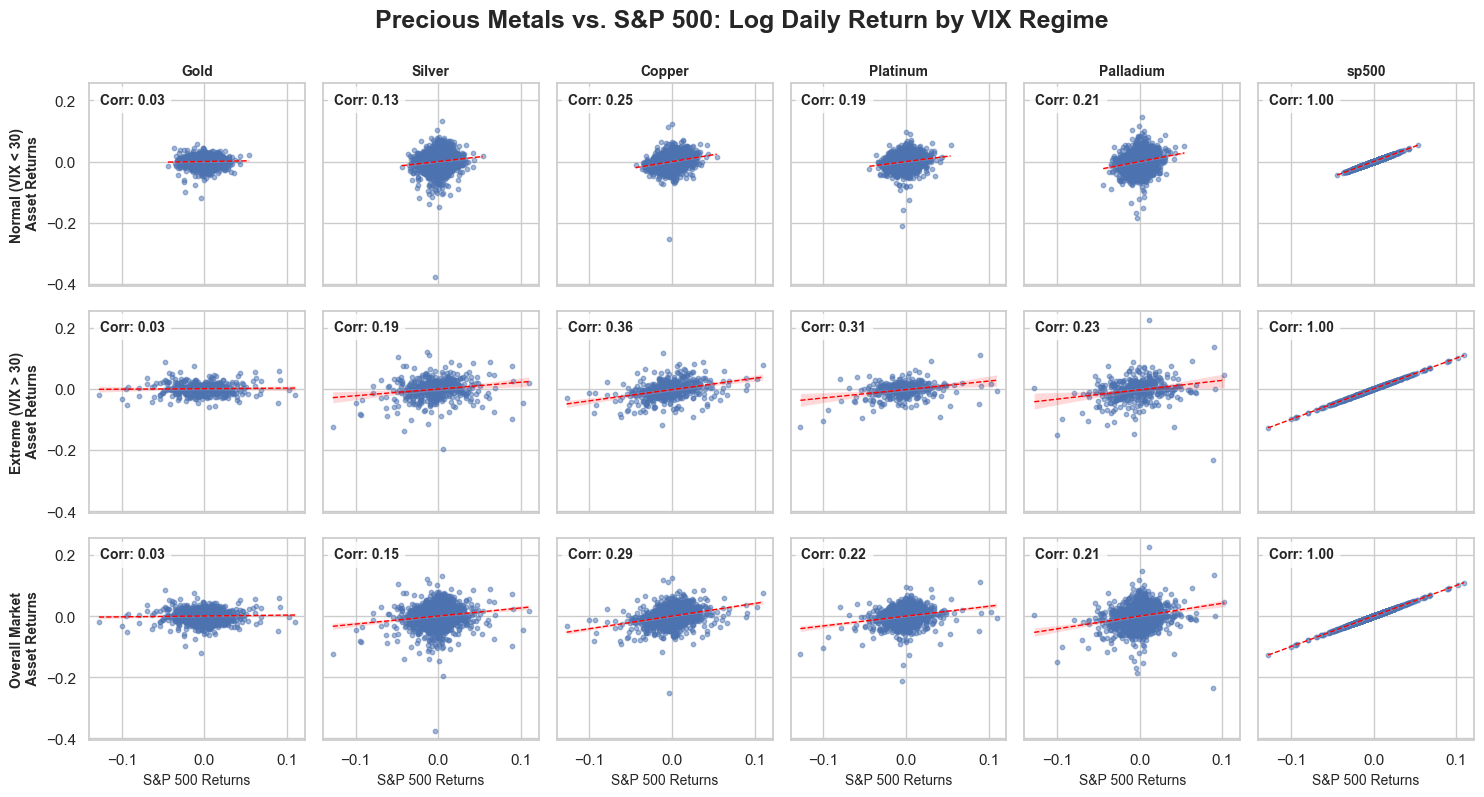

In [59]:
#asset_list = ['Copper', 'Gold', 'Palladium', 'Platinum', 'Silver', 'sp500']
n = len(asset_list)

# 2. 设置绘图风格
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8), sharex=True, sharey=True)  # 改为3行n列

# 大标题
fig.suptitle('Precious Metals vs. S&P 500: Log Daily Return by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)

regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 3. 开始循环绘图 - 调换循环顺序
for i, regime in enumerate(regimes):  # 外层循环改为regime
    for j, metal in enumerate(asset_list):  # 内层循环改为metal
        ax = axes[i, j]
        
        # 筛选数据
        if regime == 'Overall':
            plot_data = Ret_data
        else:
            plot_data = Ret_data[Ret_data['is_panic_day'] == regime]
            
        # 绘制散点图和回归线
        sns.regplot(
            data=plot_data, 
            x='sp500', 
            y=metal, 
            ax=ax, 
            scatter_kws={'alpha': 0.5, 's': 10}, 
            line_kws={'color': 'red', 'lw': 1, 'linestyle': '--'} 
        )
        
        # 计算相关系数用于标注
        corr = plot_data['sp500'].corr(plot_data[metal])
        ax.text(0.05, 0.9, f'Corr: {corr:.2f}', transform=ax.transAxes, 
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
        
        # 设置标题和标签
        if i == 0:  # 第一行显示资产名称
            ax.set_title(f'{metal}', fontsize=10, fontweight='bold')
        if j == 0:  # 第一列显示regime标题
            ax.set_ylabel(f'{regime_titles[i]}\n Asset Returns', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == 2:  # 最后一行显示x轴标签
            ax.set_xlabel('S&P 500 Returns', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
# 导出图片用于报告
# plt.savefig('Metal_SP500_Regime_Matrix.png', dpi=300)

plt.show()

## QQ-Plot

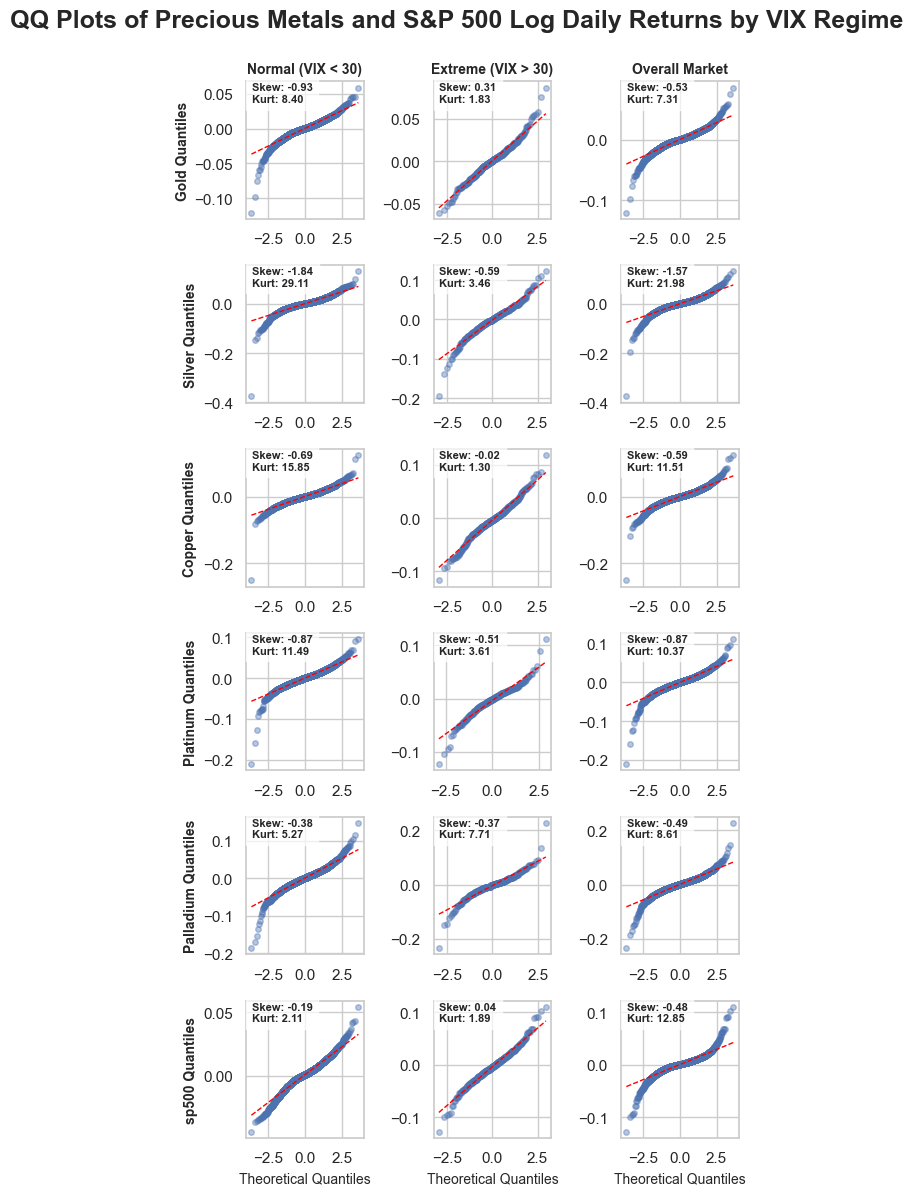

In [45]:
# 1. 准备资产和机制列表
# asset_list = ['Gold', 'Silver', 'Copper', 'Palladium', 'Platinum']



n = len(asset_list )
regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 2. 创建画布
fig, axes = plt.subplots(n, 3, figsize=(6, 2 * n))
fig.suptitle('QQ Plots of Precious Metals and S&P 500 Log Daily Returns by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)
for i, metal in enumerate(asset_list ):
    for j, regime in enumerate(regimes):
        ax = axes[i, j]
        
        # 筛选子集数据
        if regime == 'Overall':
            data = Ret_data[metal].dropna()
        else:
            data = Ret_data[Ret_data['is_panic_day'] == regime][metal].dropna()
        
        # 绘制 QQ-Plot
        # stats.probplot 会计算理论分位数并返回
        res = stats.probplot(data, dist="norm", plot=ax)
        
        # 自定义视觉效果
        ax.get_lines()[0].set_markerfacecolor('C0') # 散点颜色
        ax.get_lines()[0].set_alpha(0.4)             # 散点透明度
        ax.get_lines()[0].set_markersize(4)          # 散点大小
        ax.get_lines()[1].set_color('red')           # 45度直线颜色
        ax.get_lines()[1].set_linewidth(1)
        ax.get_lines()[1].set_linestyle('--')
        ax.set_title("")
        
        # 标注该子集的偏度和峰度，强化统计结论
        skew = data.skew()
        kurt = data.kurt()
        ax.text(0.05, 0.85, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', 
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7))

        # 设置标题和标签
        if i == 0:
            ax.set_title(regime_titles[j], fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{metal} Quantiles', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == n - 1:
            ax.set_xlabel('Theoretical Quantiles', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
# plt.savefig('Metal_QQPlot_Regime_Matrix.png', dpi=300)
plt.show()

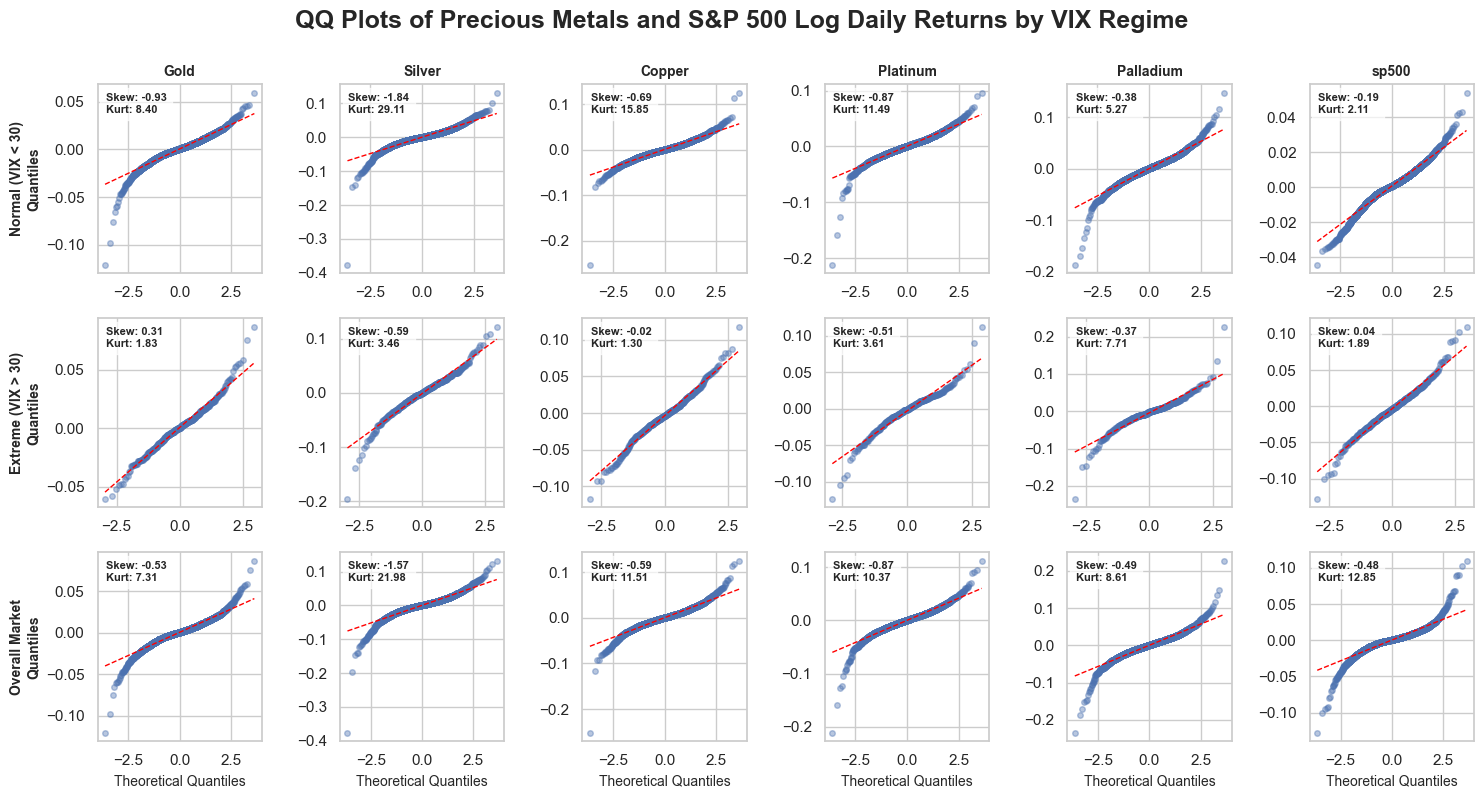

In [46]:
# 1. 准备资产和机制列表
# asset_list = ['Gold', 'Silver', 'Copper', 'Palladium', 'Platinum']
n = len(asset_list)
regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 2. 创建画布 - 改为横向：3行 n列
fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8))  # 调换行列，调整 figsize
fig.suptitle('QQ Plots of Precious Metals and S&P 500 Log Daily Returns by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)
for i, regime in enumerate(regimes):  # 外层循环改为 regime
    for j, metal in enumerate(asset_list):  # 内层循环改为 metal
        ax = axes[i, j]
        
        # 筛选子集数据
        if regime == 'Overall':
            data = Ret_data[metal].dropna()
        else:
            data = Ret_data[Ret_data['is_panic_day'] == regime][metal].dropna()
        
        # 绘制 QQ-Plot
        res = stats.probplot(data, dist="norm", plot=ax)
        
        # 自定义视觉效果
        ax.get_lines()[0].set_markerfacecolor('C0')
        ax.get_lines()[0].set_alpha(0.4)
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.get_lines()[1].set_linewidth(1)
        ax.get_lines()[1].set_linestyle('--')
        ax.set_title("")
        
        # 标注该子集的偏度和峰度
        skew = data.skew()
        kurt = data.kurt()
        ax.text(0.05, 0.85, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', 
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7))

        # 设置标题和标签
        if i == 0:
            ax.set_title(f'{metal}', fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{regime_titles[i]}\nQuantiles', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == 2:  # 最后一行
            ax.set_xlabel('Theoretical Quantiles', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
# plt.savefig('Metal_QQPlot_Regime_Matrix.png', dpi=300)
plt.show()

In [53]:
events_df = pd.read_csv('data/global_market_stress_events.csv')
events_df.head()

,Event Name,Abbreviation,Start Date,End Date,Primary Risk Driver
0,Global Financial Crisis,GFC,15/8/2007,8/7/2009,Systemic Banking Collapse / Liquidity Risk
1,Flash Crash & Eurozone Crisis I,EZC-I,6/5/2010,2/7/2010,Algorithmic Trading / Sovereign Debt
2,US Credit Rating Downgrade,US-DWN,4/8/2011,8/12/2011,US Treasury Risk / Fiscal Policy
3,China Market Turbulence,CHN-VOL,24/8/2015,1/9/2015,Emerging Market Contagion / FX Devaluation
4,Volmageddon & Late-Cycle Correction,VOL-MAX,5/2/2018,26/12/2018,Quantitative Tightening / VIX Product Collapse


## Rolling Correlation 

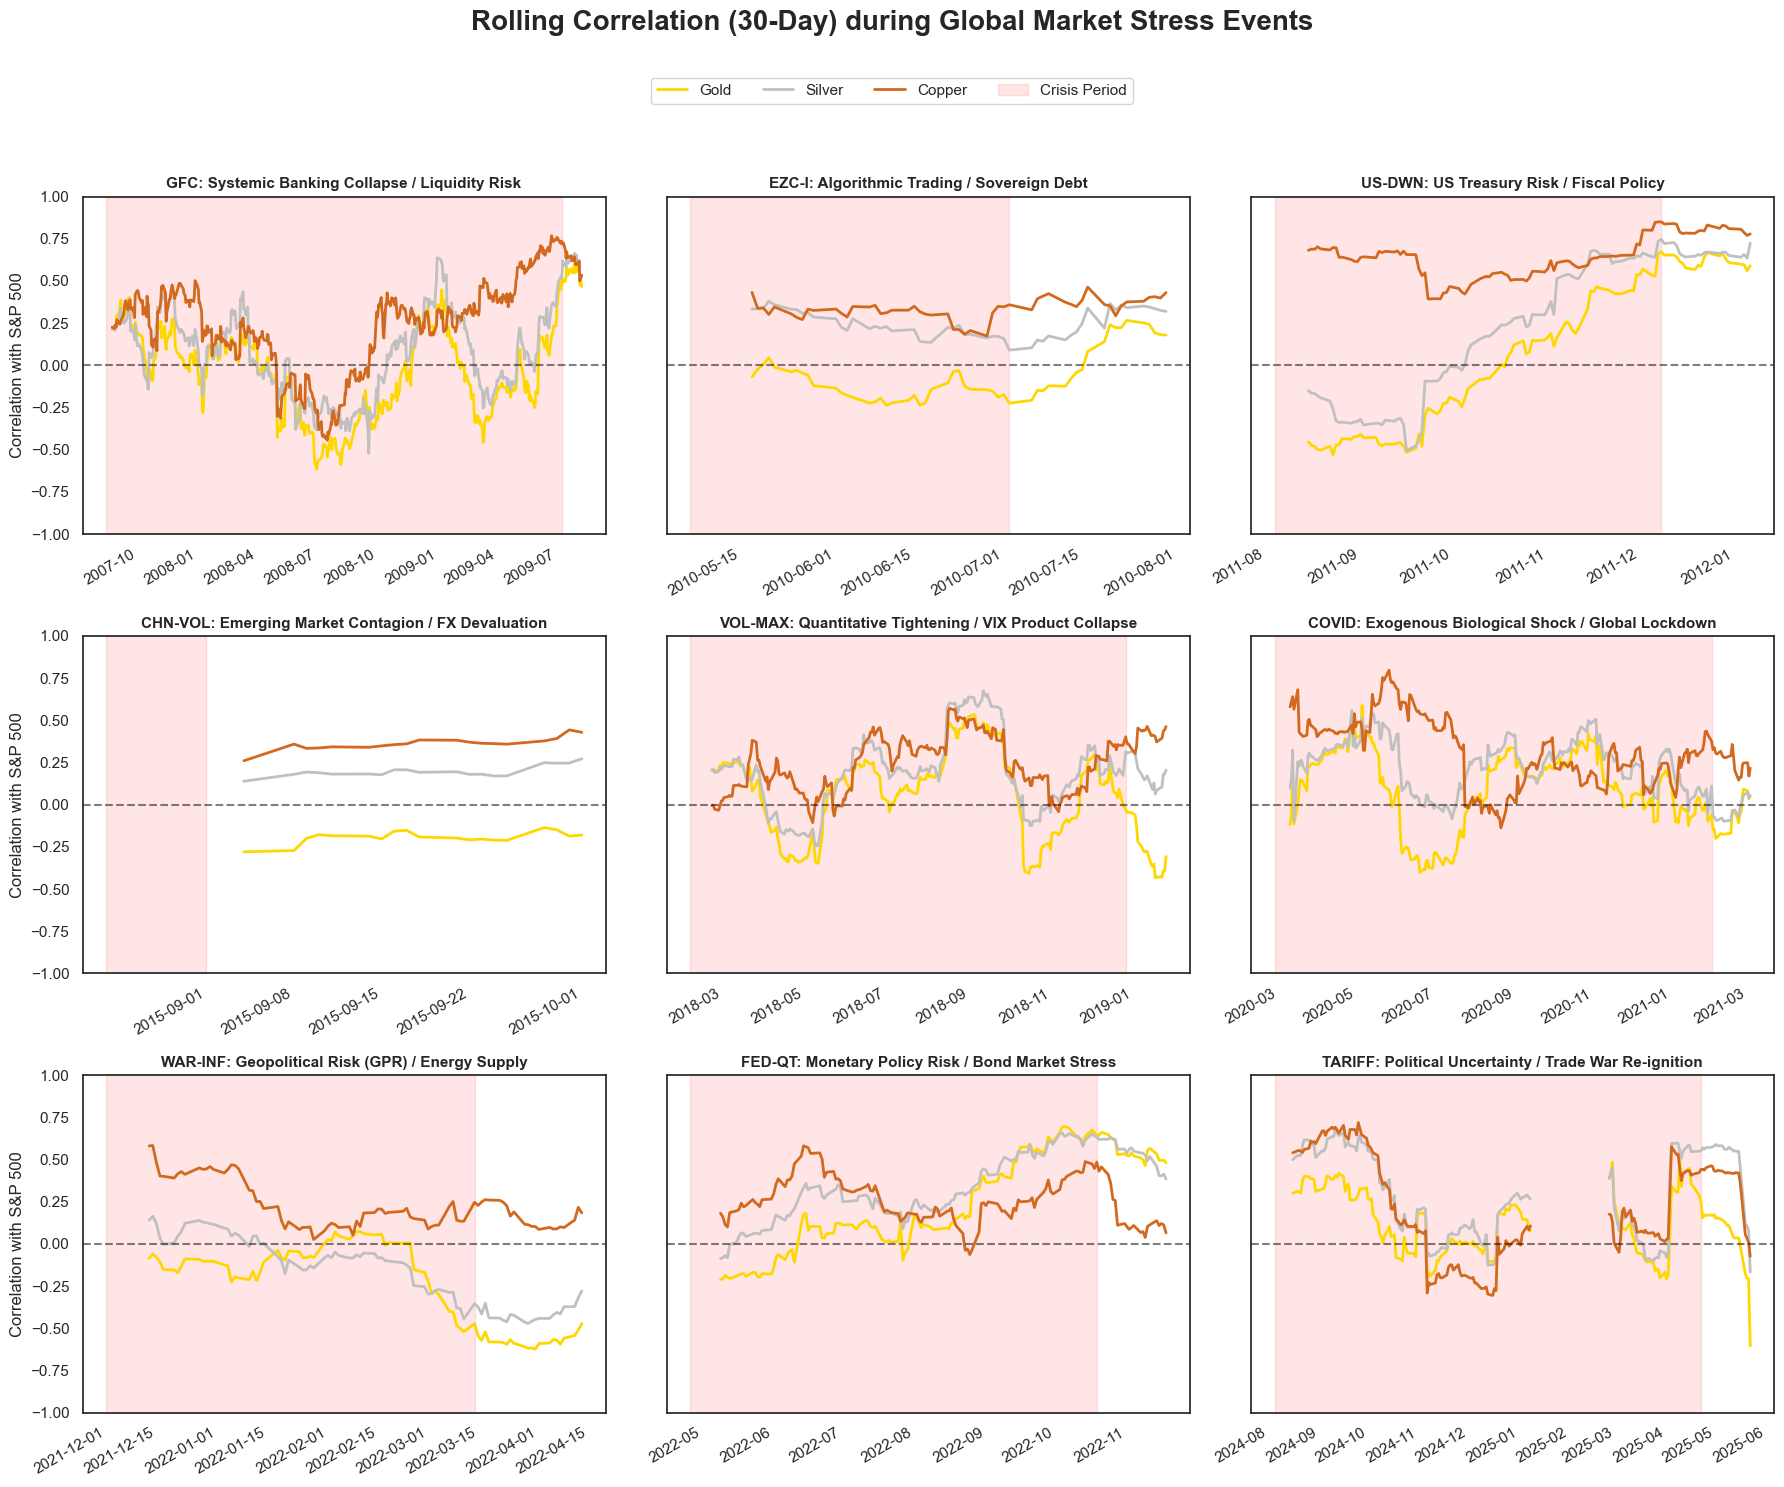

In [55]:
# 假设 events_df 是你提供的包含 Start Date 和 End Date 的 DataFrame
# 确保日期列是 datetime 格式
events_df['Start Date'] = pd.to_datetime(events_df['Start Date'], dayfirst=True)
events_df['End Date'] = pd.to_datetime(events_df['End Date'], dayfirst=True)

# 设置参数
window = 30  # 危机期间建议窗口调小（如30天），以捕捉快速变化的相关性
metals = ['Gold', 'Silver', 'Copper']
colors = {'Gold': 'gold', 'Silver': 'silver', 'Copper': 'chocolate'}

# 创建 3x3 画布
fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey=True)
axes = axes.flatten() # 展平以便遍历

for i, (idx, row) in enumerate(events_df.iterrows()):
    if i >= 9: break  # 仅画前9个事件
    
    ax = axes[i]
    event_name = row['Abbreviation']
    start, end = row['Start Date'], row['End Date']
    
    # 稍微拓宽时间范围以便观察危机前后的对比 (比如提前30天，延后30天)
    plot_start = start - pd.Timedelta(days=30)
    plot_end = end + pd.Timedelta(days=30)
    
    # 切片数据
    mask = (Ret_data.index >= plot_start) & (Ret_data.index <= plot_end)
    subset = Ret_data.loc[mask]
    
    for metal in metals:
        # 计算滚动相关性
        roll_corr = subset[metal].rolling(window=window).corr(subset['sp500'])
        ax.plot(roll_corr, label=f'{metal}', color=colors[metal], lw=2)
    
    # 标记实际危机发生的区间
    ax.axvspan(start, end, color='red', alpha=0.1, label='Crisis Period')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # 格式化子图
    ax.set_title(f"{event_name}: {row['Primary Risk Driver']}", fontsize=11, fontweight='bold')
    ax.set_ylim(-1, 1)
    if i % 3 == 0: ax.set_ylabel("Correlation with S&P 500")
    
    # 设置日期显示格式（避免重叠）
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 处理多余的子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 全局美化
plt.suptitle(f"Rolling Correlation ({window}-Day) during Global Market Stress Events", fontsize=20,fontweight = 'bold', y=1.02)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Maximum Drawback Comparison

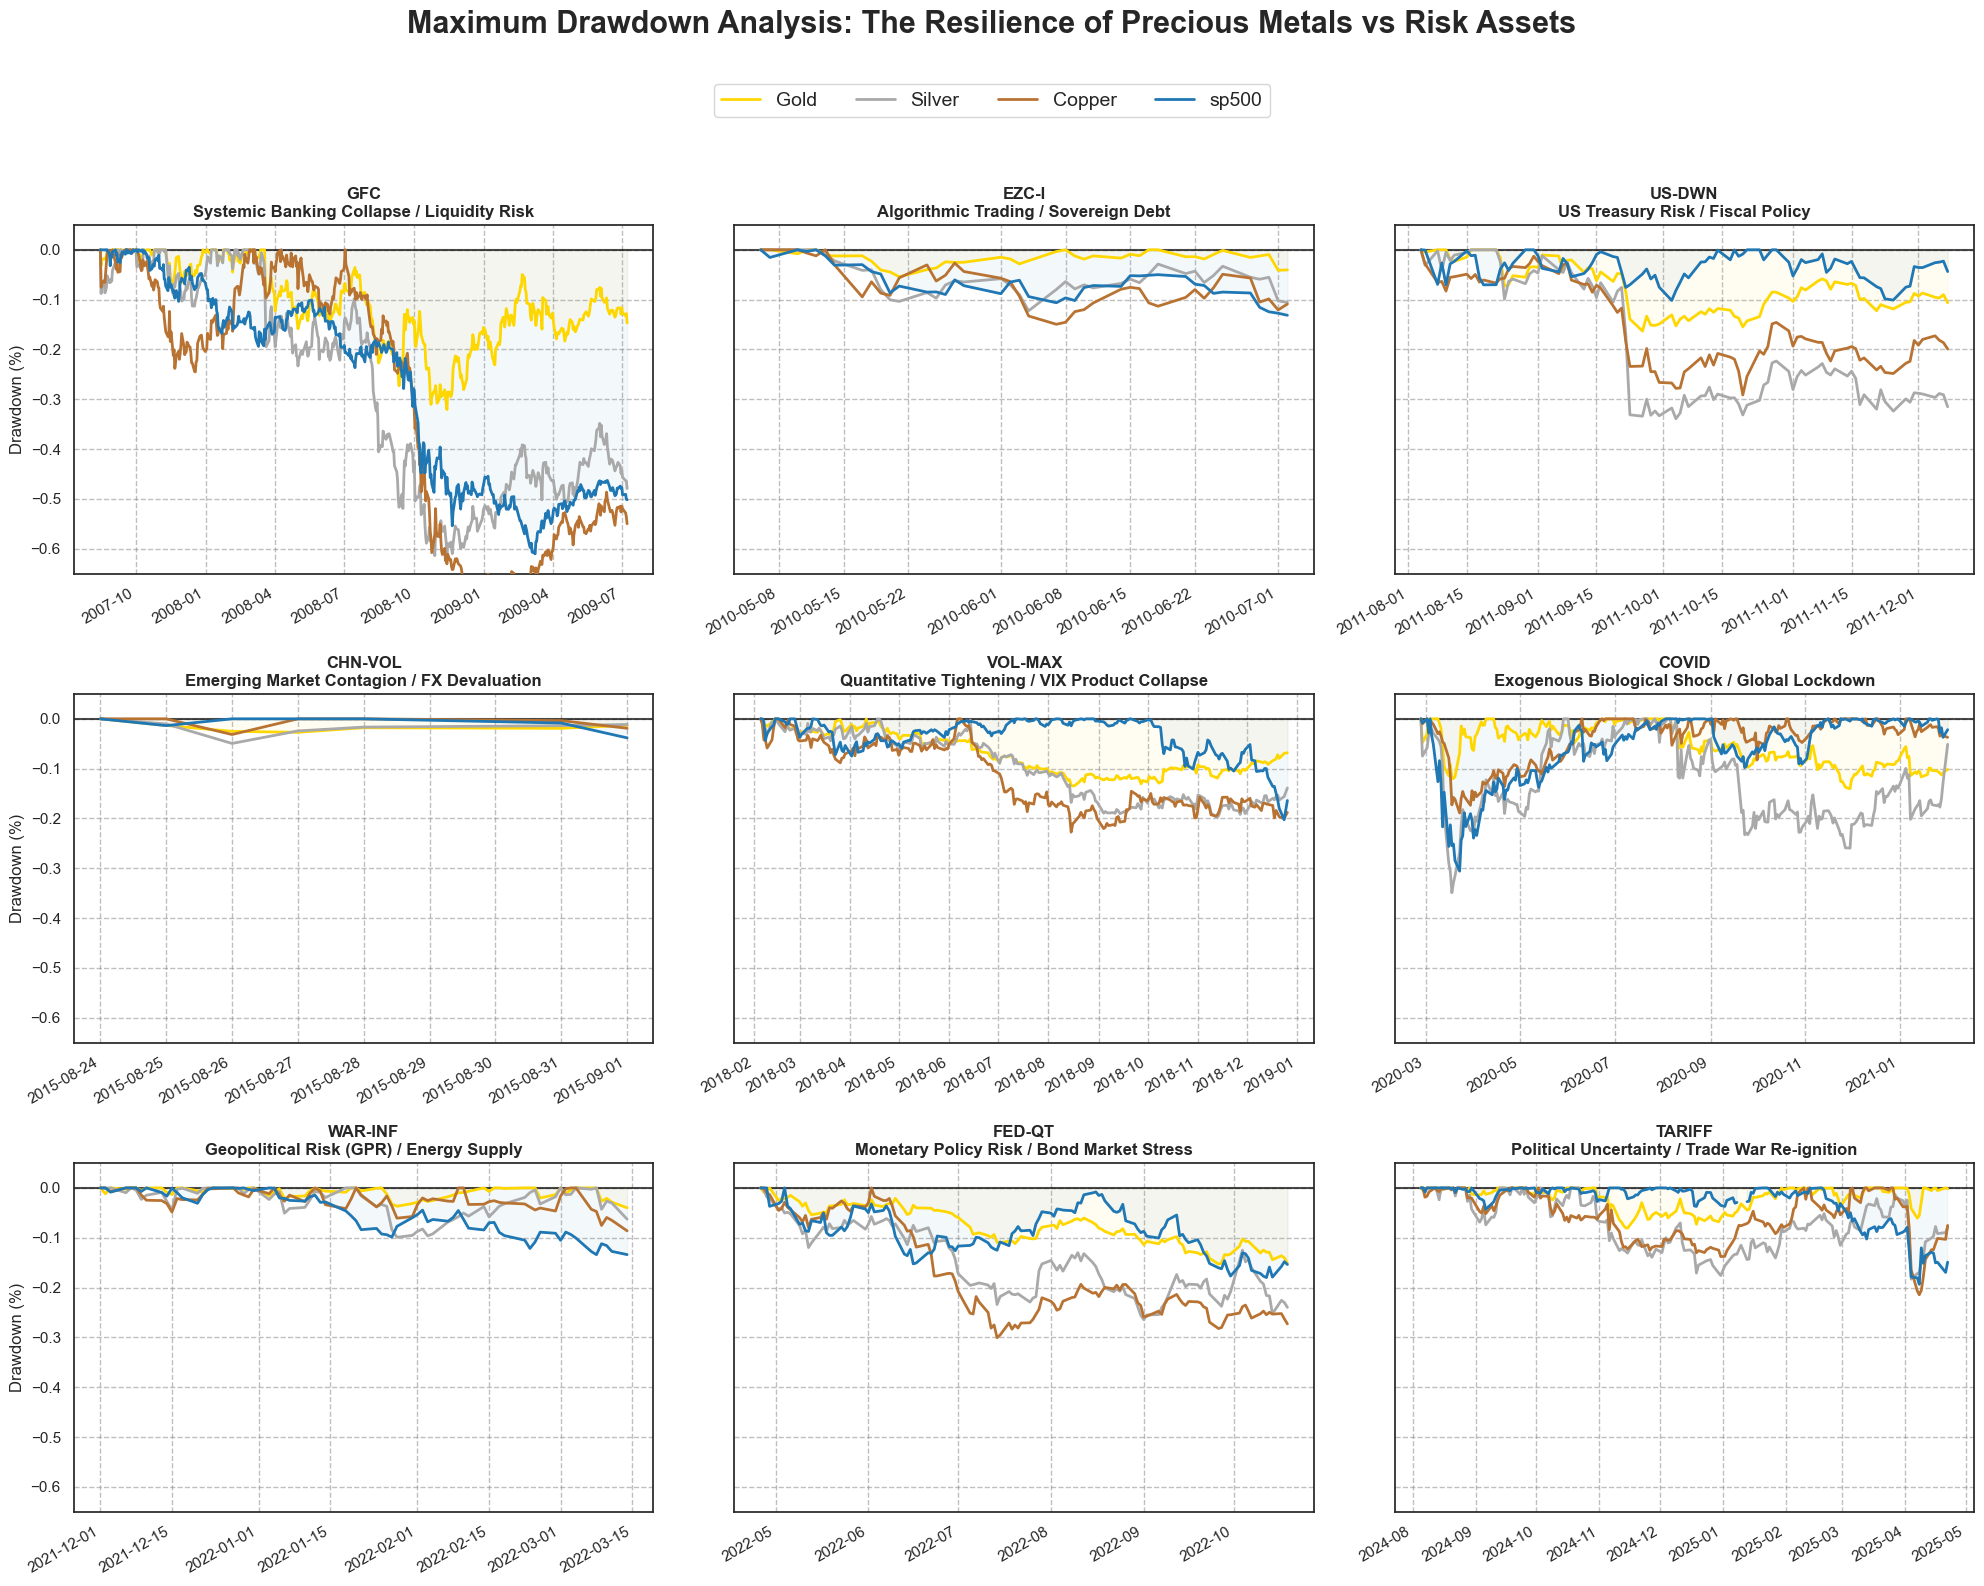

In [ ]:
# 确保日期格式正确
events_df['Start Date'] = pd.to_datetime(events_df['Start Date'], dayfirst=True)
events_df['End Date'] = pd.to_datetime(events_df['End Date'], dayfirst=True)

# 资产配置：增加白银 (Silver) 并设置专业配色
assets_to_compare = ['Gold', 'Silver', 'Copper', 'sp500'] 
colors = {
    'Gold': '#FFD700',    # 金色
    'Silver': '#A9A9A9',  # 深灰色（代表白银）
    'Copper': '#B87333',  # 铜色
    'sp500': '#1f77b4'    # 蓝色（标普500）
}

fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, (idx, row) in enumerate(events_df.iterrows()):
    if i >= 9: break
    
    ax = axes[i]
    start, end = row['Start Date'], row['End Date']
    
    # 提取危机期间的数据
    mask = (Ret_data.index >= start) & (Ret_data.index <= end)
    subset = Ret_data.loc[mask].copy()
    
    if subset.empty: continue

    for asset in assets_to_compare:
        # 1. 计算累积收益率
        cum_ret = (1 + subset[asset]).cumprod()
        
        # 2. 计算滚动最高点
        running_max = cum_ret.cummax()
        
        # 3. 计算回撤 (Drawdown)
        drawdown = (cum_ret / running_max) - 1
        
        # 4. 绘制曲线
        ax.plot(drawdown, label=asset, color=colors[asset], lw=2, zorder=3)
        # 为最核心的黄金和标普500添加轻微填充，增强对比感
        if asset in ['Gold', 'sp500']:
            ax.fill_between(drawdown.index, drawdown, 0, color=colors[asset], alpha=0.05)

    # --- 修改建议 1：添加灰色网格线 ---
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.5, zorder=1)
    
    # 格式化子图
    ax.set_title(f"{row['Abbreviation']}\n{row['Primary Risk Driver']}", fontsize=12, fontweight='bold')
    ax.set_ylim(-0.65, 0.05) # 稍微扩大纵轴范围以容纳白银可能的波动
    ax.axhline(0, color='black', lw=1.5, alpha=0.7, zorder=2)
    
    if i % 3 == 0:
        ax.set_ylabel("Drawdown (%)", fontsize=12)
    
    # 日期刻度美化
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 清理多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Maximum Drawdown Analysis: The Resilience of Precious Metals vs Risk Assets", fontsize=22, fontweight = 'bold', y=1.02)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [38]:
df = pd.read_csv(r'C:\Users\jimmy\OneDrive\Work\25秋招准备综合\工作申请追踪\US Summer Intern.csv')
jd_text = df.loc[df['Company'] == 'Blidz', 'JD'].values[0]
print(jd_text)

Company Description

Blidz brings together brilliant minds from Helsinki, Shanghai, and New York. We're growing rapidly and steadily, hitting $20MUSD in ARR and fully profitable. We've raised millions from top-tier VCs like General Catalyst and angels like David Helgason (Unity founder), and we're gearing up for Series A – perfect timing to jump in and feel the 1->100 vibes!



Role Description

As a Data Analytics Intern (In-Semester), you'll crunch numbers, uncover insights, and help drive our growth strategies. You'll work closely with our senior engineers and analytical wizards in a flat, no-hierarchy setup – we skip the busywork and focus on real problem-solving. This role blends analytical prowess with creativity to optimize user experiences in our entertainment shopping world.



Responsibilities

Support the team in building dashboards and reports using tools like Excel, SQL, or Python to track key performance indicators.
Analyze user data from social channels, app interactions